<a href="https://colab.research.google.com/github/castudil/Machine-Learning/blob/main/S09-Support-Vector-Machines/S09_LAB_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de Máquinas de Soporte Vectorial en Python

## Objetivo
El objetivo de este laboratorio es experimentar con un conjunto de datos artificial que sigue una distribución Gaussiana creada por el programador. Utilizaremos el kernel Gaussiano para aprender la estructura utilizando máquinas de Soporte Vectorial.


## Etapas Metodológicas

Se deben seguir las siguientes cinco etapas metodológicas:

1. **Obtención de datos**: Generar un conjunto de datos artificial siguiendo una distribución Gaussiana.

2. **Manipulación**: Dividir el conjunto de datos en conjuntos de entrenamiento, prueba y validación.

3. **Exploración**: Visualizar los datos para entender la distribución y la relación entre las categorías.

4. **Modelamiento**: Implementar un clasificador de Máquinas de Soporte Vectorial utilizando el kernel Gaussiano.

5. **Interpretación**: Analizar y discutir los resultados obtenidos, incluyendo las estadísticas de clasificación y los parámetros ajustados.

## Instrucciones

1. Crea un Jupyter notebook para llevar a cabo el laboratorio.

2. Genera un conjunto de datos artificial que siga una distribución Gaussiana concéntrica.

3. Divide el conjunto de datos en conjuntos de entrenamiento, prueba y validación.

4. Grafica los conjuntos de datos, asignando el color rojo a una categoría y el color azul a la otra.

5. Entrena un clasificador de Máquinas de Soporte Vectorial utilizando el kernel Gaussiano.

6. Muestra las estadísticas de clasificación (precisión, recall, F1-score, etc.).

7. Realiza ajustes en los parámetros del clasificador y documenta los cambios en el rendimiento.

8. Interpreta los resultados y concluye sobre la eficacia del modelo.

9. Entrega el Jupyter notebook con todos los pasos y explicaciones detalladas.

Recuerda documentar cada paso y proporcionar explicaciones claras y concisas en tu notebook. ¡Buena suerte!



#PASO 1 Obtención de datos

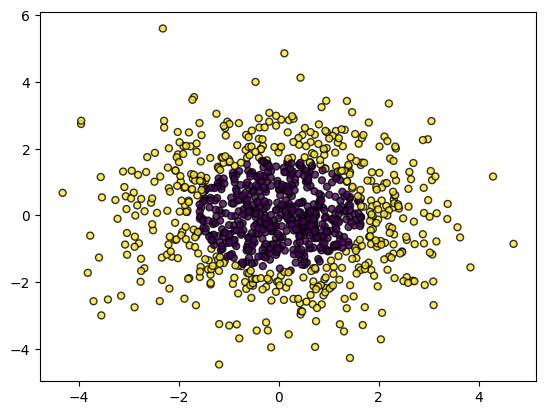

In [ ]:
# create two gaussian distributions using make_gaussian_quantiles

from sklearn.datasets import make_gaussian_quantiles
import matplotlib.pyplot as plt
import numpy as np

# generate 2D normally distributed data
X1, Y1 = make_gaussian_quantiles(
    cov=2.0, n_samples=1000, n_features=2, n_classes=2, random_state=1
)

# plot  data. Seaborn, blue a red color, transparency.

plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k", alpha=0.8)
plt.show()

# PASO 2: Manipulación de datos


In [3]:
from sklearn.model_selection import train_test_split

# Separación en entrenamiento+validación y prueba (20% para prueba)
X_temp, X_test, y_temp, y_test = train_test_split(
    X1, Y1, test_size=0.2, random_state=42, stratify=Y1
)

# Separación entrenamiento y validación (20% de lo restante para validación)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print("Tamaño conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño conjunto de validación:", X_val.shape[0])
print("Tamaño conjunto de prueba:", X_test.shape[0])

Tamaño conjunto de entrenamiento: 640
Tamaño conjunto de validación: 160
Tamaño conjunto de prueba: 200


#PASO 3: Exploración de Datos

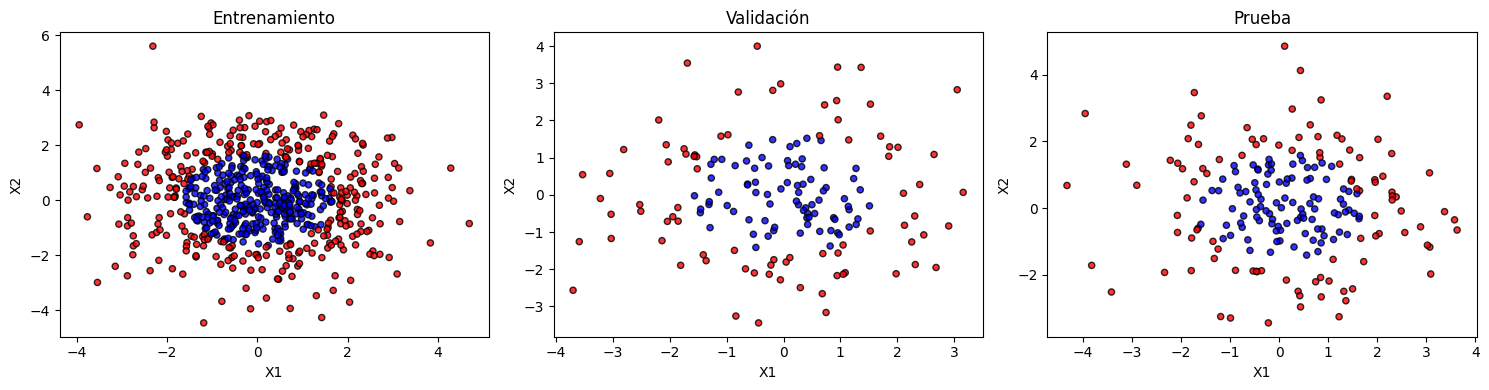

In [4]:
# Visualización de los conjuntos de entrenamiento, validación y prueba

import matplotlib.pyplot as plt
import numpy as np

colors = np.array(["blue", "red"])

plt.figure(figsize=(15, 4))

# Entrenamiento
plt.subplot(1, 3, 1)
plt.scatter(
    X_train[:, 0], X_train[:, 1], c=colors[y_train], s=20, edgecolor="k", alpha=0.8
)
plt.title("Entrenamiento")
plt.xlabel("X1")
plt.ylabel("X2")

# Validación
plt.subplot(1, 3, 2)
plt.scatter(X_val[:, 0], X_val[:, 1], c=colors[y_val], s=20, edgecolor="k", alpha=0.8)
plt.title("Validación")
plt.xlabel("X1")
plt.ylabel("X2")

# Prueba
plt.subplot(1, 3, 3)
plt.scatter(
    X_test[:, 0], X_test[:, 1], c=colors[y_test], s=20, edgecolor="k", alpha=0.8
)
plt.title("Prueba")
plt.xlabel("X1")
plt.ylabel("X2")

plt.tight_layout()
plt.show()

# PASO 4: Modelamiento de Datos (Machine Learning)

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Entrenar el clasificador SVM con kernel RBF (Gaussiano)
svm_clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_clf.fit(X_train, y_train)

# Evaluación en el conjunto de validación
y_val_pred = svm_clf.predict(X_val)
print("Resultados en el conjunto de validación:")
print(classification_report(y_val, y_val_pred))

# Evaluación en el conjunto de prueba
y_test_pred = svm_clf.predict(X_test)
print("Resultados en el conjunto de prueba:")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión para el conjunto de prueba
print("Matriz de confusión (prueba):")
print(confusion_matrix(y_test, y_test_pred))

Resultados en el conjunto de validación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        80
           1       1.00      0.97      0.99        80

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160

Resultados en el conjunto de prueba:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       100
           1       0.96      0.99      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200

Matriz de confusión (prueba):
[[96  4]
 [ 1 99]]


#PASO 5: Interpretación de los Resultados

In [6]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(
        X, Y, P, colors="k", levels=[-1, 0, 1], alpha=0.5, linestyles=["--", "-", "--"]
    )

    # plot support vectors
    if plot_support:
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidth=1,
            facecolors="none",
        )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

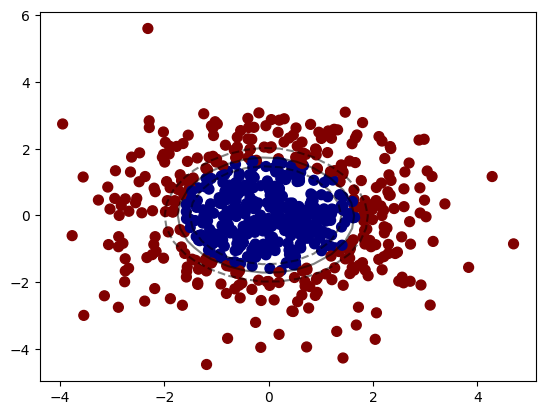

In [10]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap="jet")
plot_svc_decision_function(svm_clf)

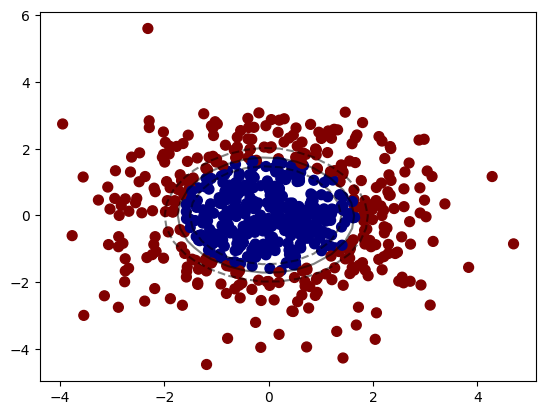

In [11]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap="jet")
plot_svc_decision_function(svm_clf)
plt.scatter(
    svm_clf.support_vectors_[:, 0],
    svm_clf.support_vectors_[:, 1],
    s=300,
    lw=1,
    facecolors="none",
)

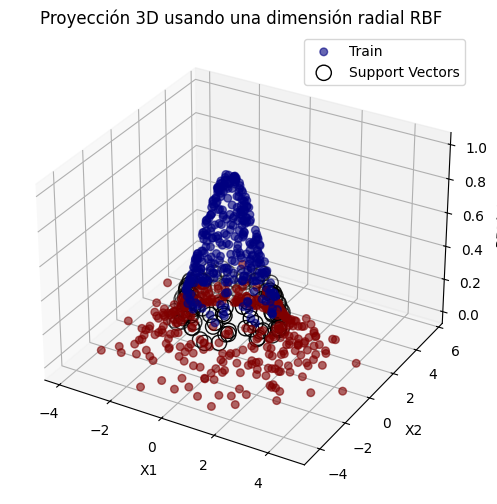

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np


# Calcula la dimensión radial (r) para cada punto
def rbf_feature(X, gamma=0.5):
    # Usamos la norma al origen como ejemplo de proyección radial
    return np.exp(-gamma * np.sum(X**2, axis=1))


r_train = rbf_feature(X_train)
r_sv = rbf_feature(svm_clf.support_vectors_)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Muestra los datos de entrenamiento
ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    r_train,
    c=y_train,
    cmap="jet",
    s=30,
    alpha=0.6,
    label="Train",
)

# Muestra los vectores de soporte
ax.scatter(
    svm_clf.support_vectors_[:, 0],
    svm_clf.support_vectors_[:, 1],
    r_sv,
    facecolors="none",
    edgecolors="k",
    s=120,
    label="Support Vectors",
)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("RBF(X)")
ax.set_title("Proyección 3D usando una dimensión radial RBF")
ax.legend()
plt.show()

En base a los gráficos, el SVM con kernel Gaussiano logró separar bien las dos clases: en el gráfico 3D se observa que los puntos azules (clase 0) quedan elevados y los rojos (clase 1) abajo, y en el 2D el azul está en el centro y el rojo más afuera. Además, las métricas de precision, recall y f1-score son buenas, lo que indica que el modelo funciona bien para este tipo de datos. No pareciera existir overfitting. Por último los vectores de soporte ayudan a ver cómo el modelo define la frontera.